In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True)

    oof, pred, result_dict = cv_score.score()

    score = np.sqrt(mean_squared_error(y_true=target, y_pred=oof))
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.plot_regression_predictions(data=data, true_label=target, pred_label=oof, feature=["delta_Seed"])

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = np.sqrt(mean_squared_error(y_true=test_target, y_pred=pred))
        print(f"Test score: {score}")
        tml.plot_regression_predictions(data=test_data, true_label=test_target, pred_label=pred, feature=["delta_Seed"])

    return oof, pred, result_dict

In [3]:
df = pd.read_csv("data/processed/men_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

In [12]:
result_dict["feat_imp"].tail(20)["Feature"].to_list()

['delta_FGM_no_ast_diff',
 'delta_FGM3_perc',
 'delta_TO',
 'delta_PF_diff',
 'delta_FT_perc',
 'delta_FGM3_diff',
 'delta_Ast_diff',
 'delta_Stl',
 'delta_PF',
 'delta_TO_perposs',
 'delta_FGM2_diff',
 'delta_opp_FGM3',
 'delta_FGM_diff',
 'delta_Stl_diff',
 'delta_opp_FGA',
 'delta_OT_win_perc',
 'delta_OT_win',
 'delta_Ast_TO_ratio_diff',
 'delta_Ast_TO_ratio',
 'delta_quality']

OOF score: 11.224273097779953


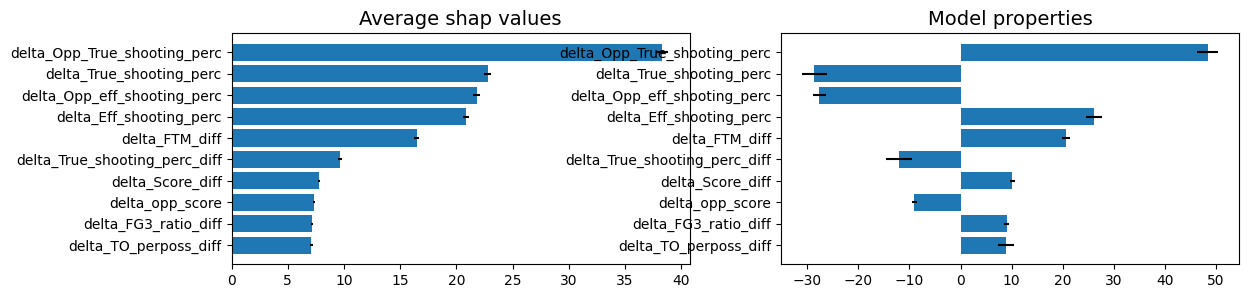

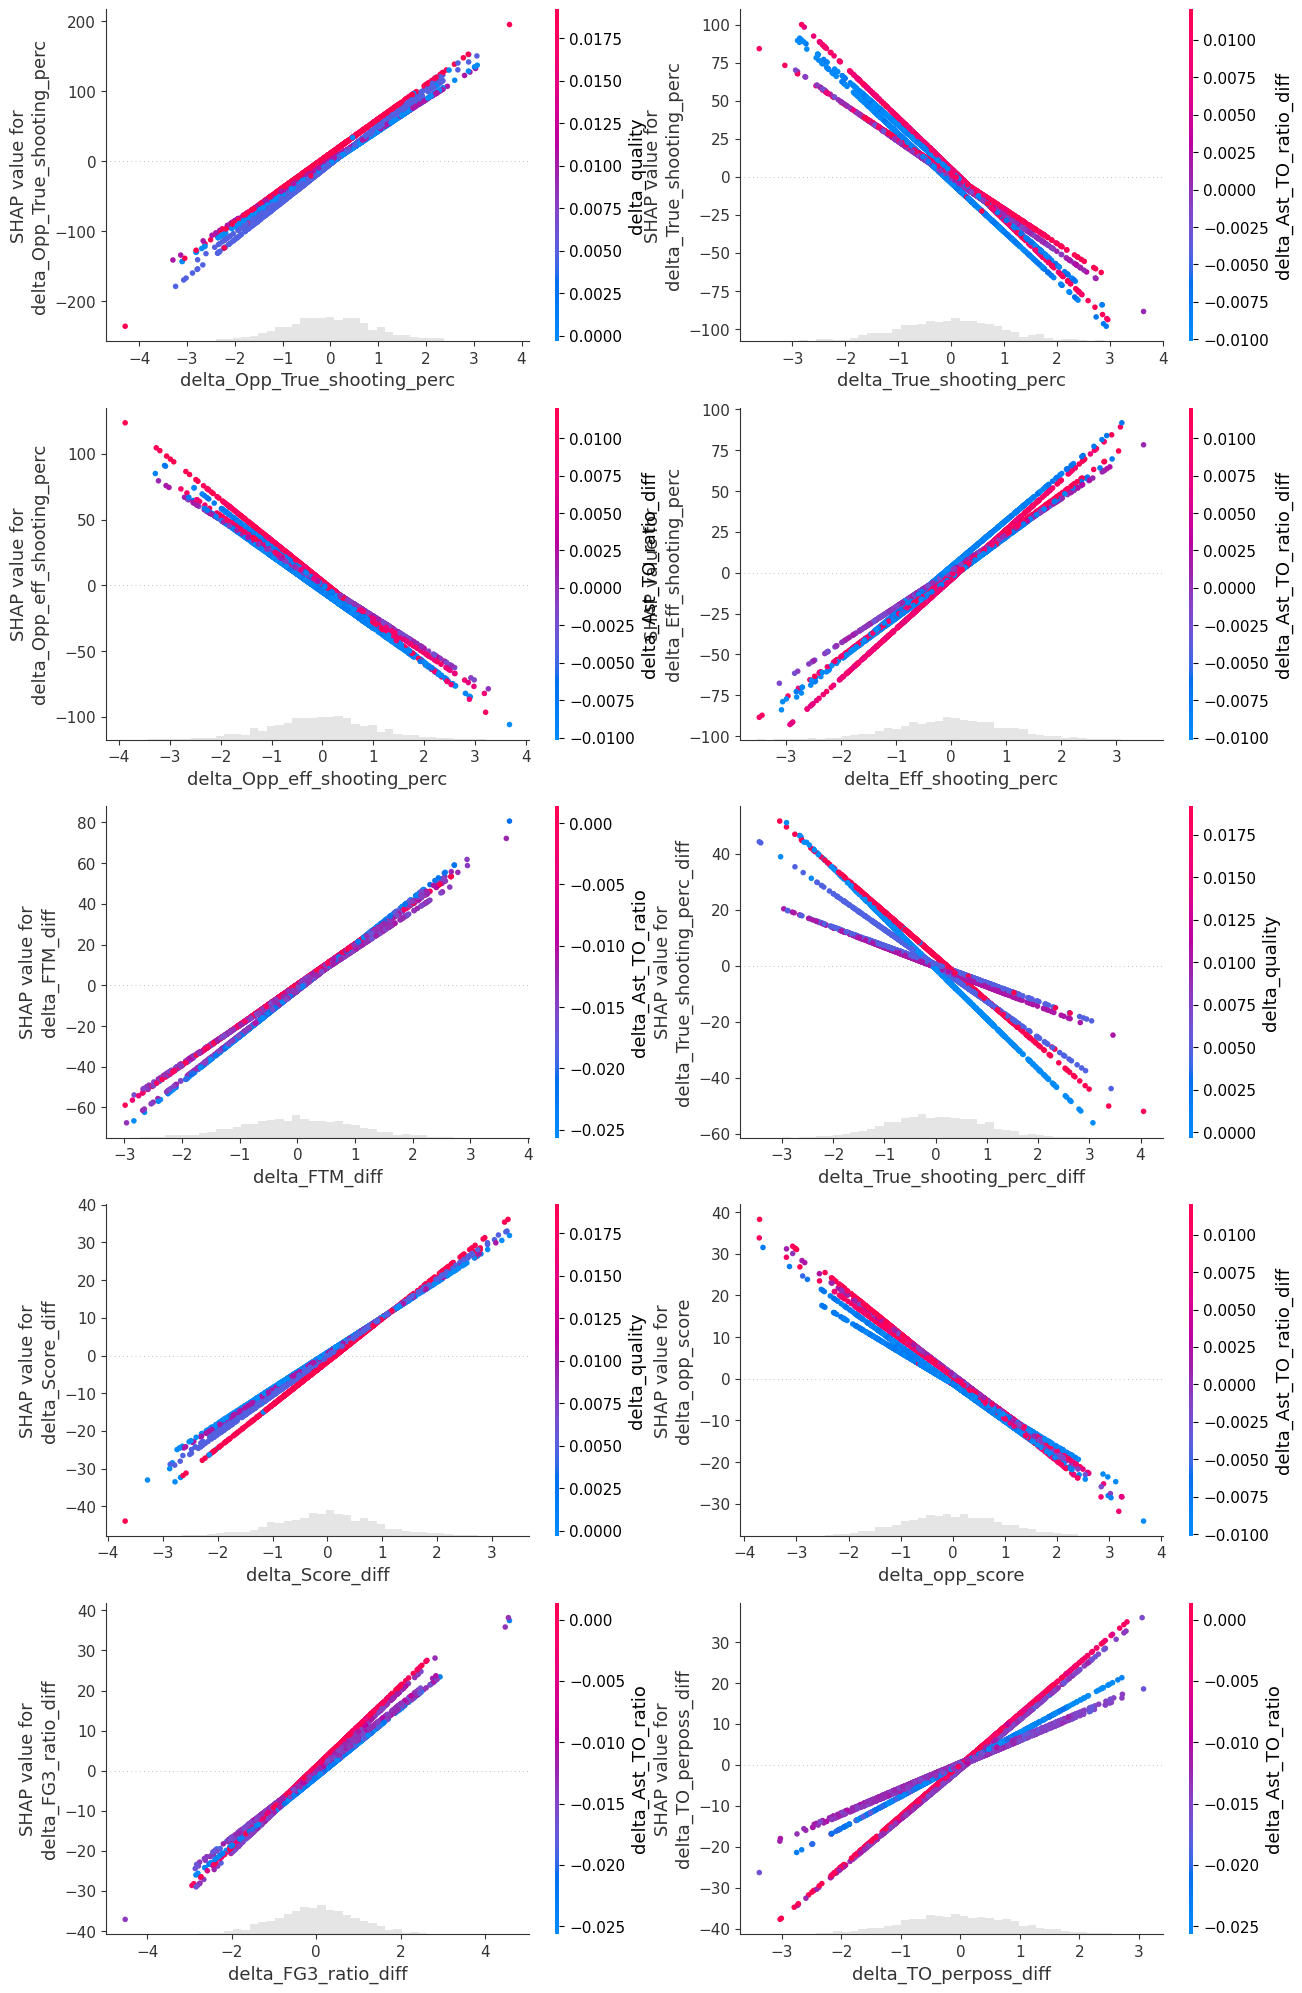

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


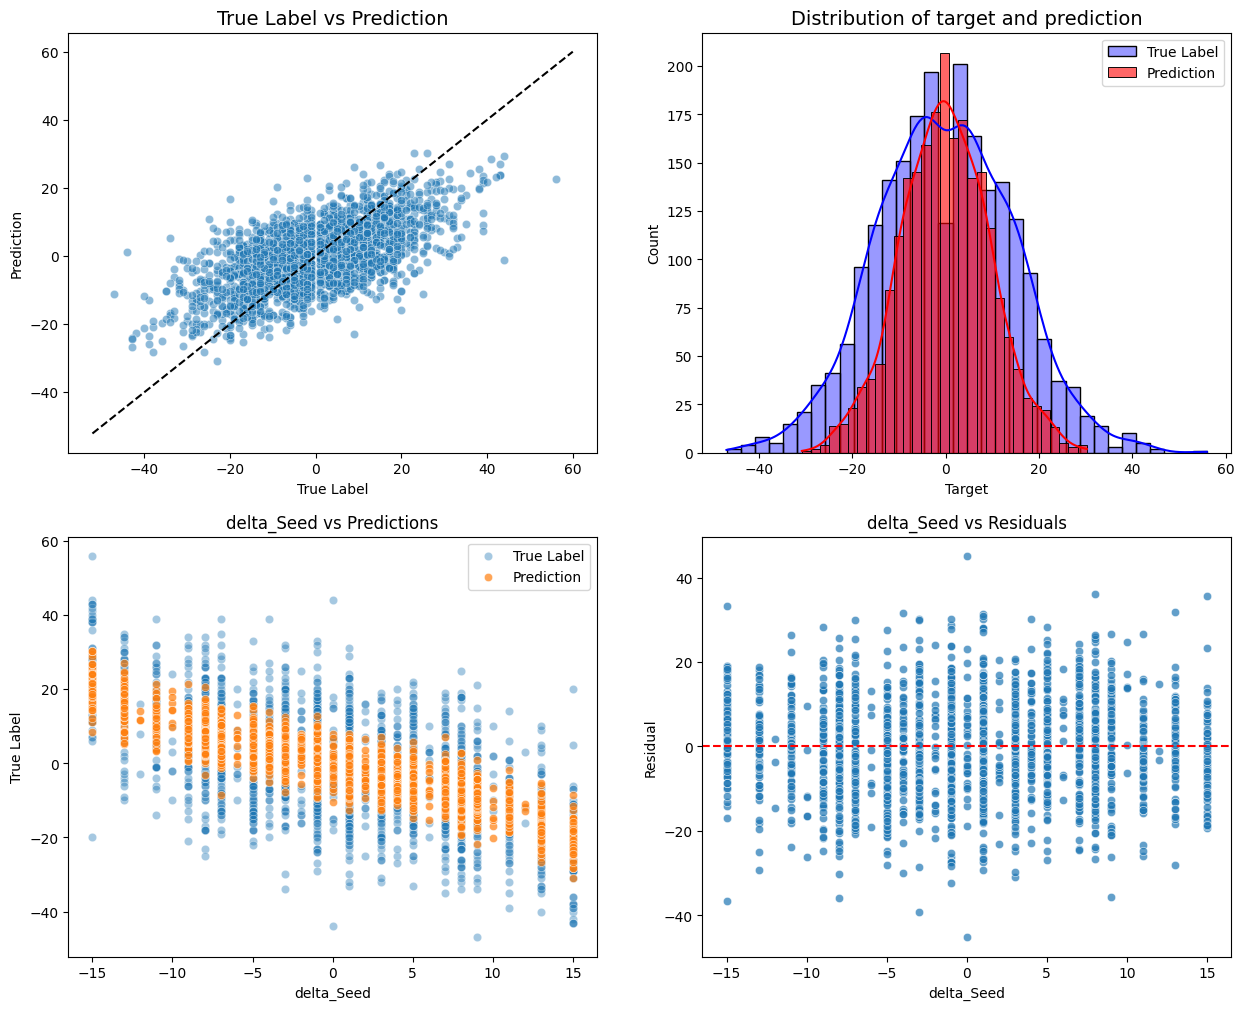

Test score: 11.831137045584839


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


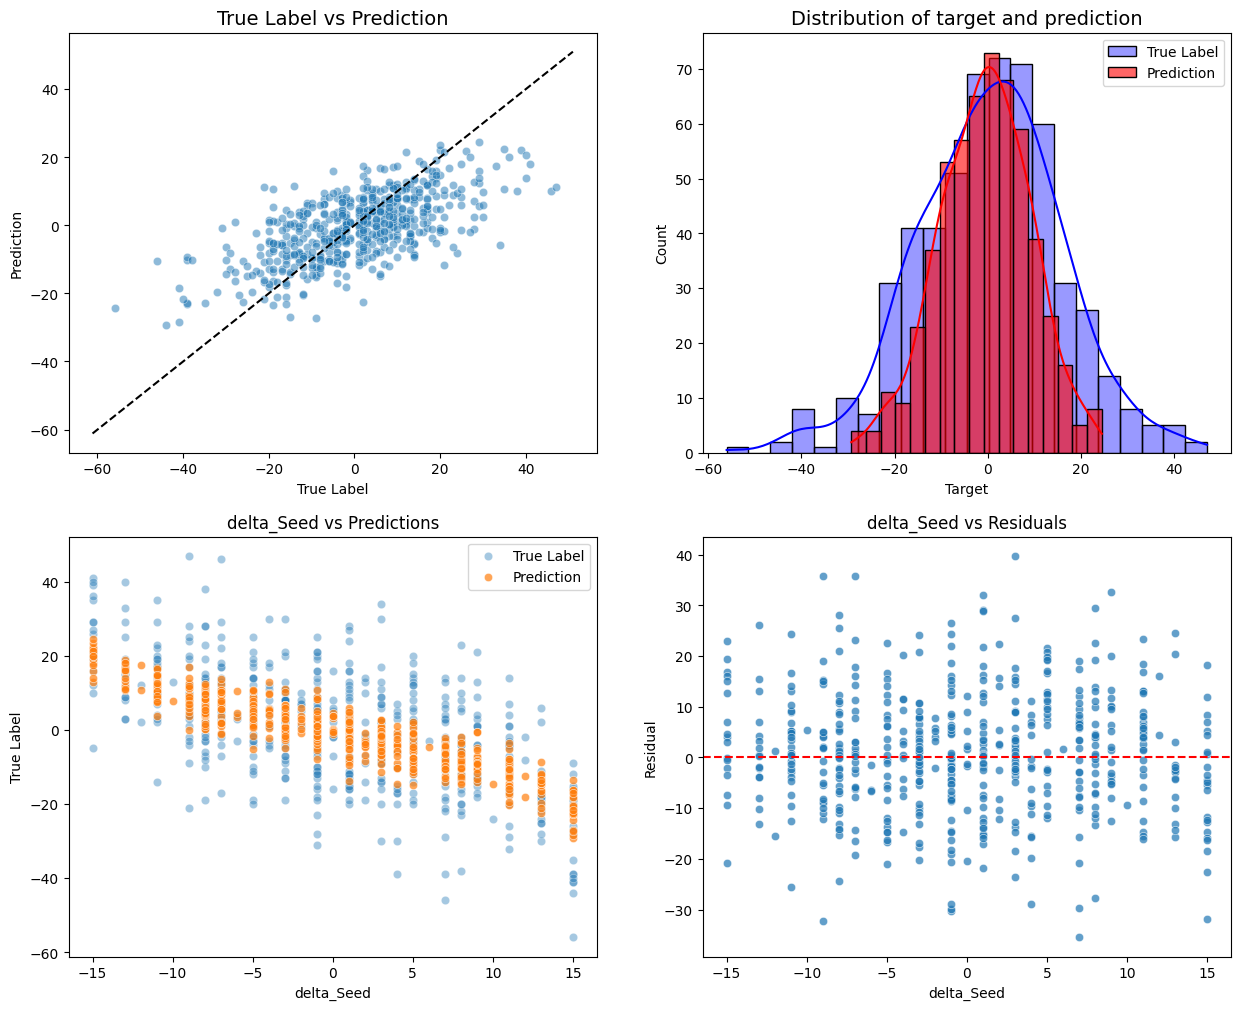

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


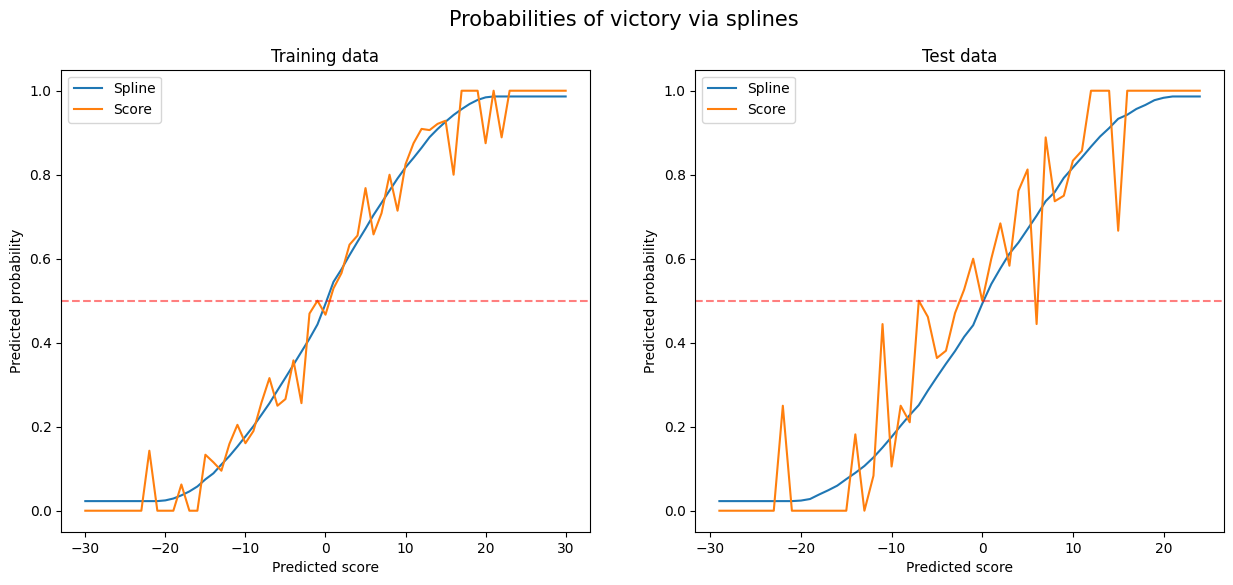

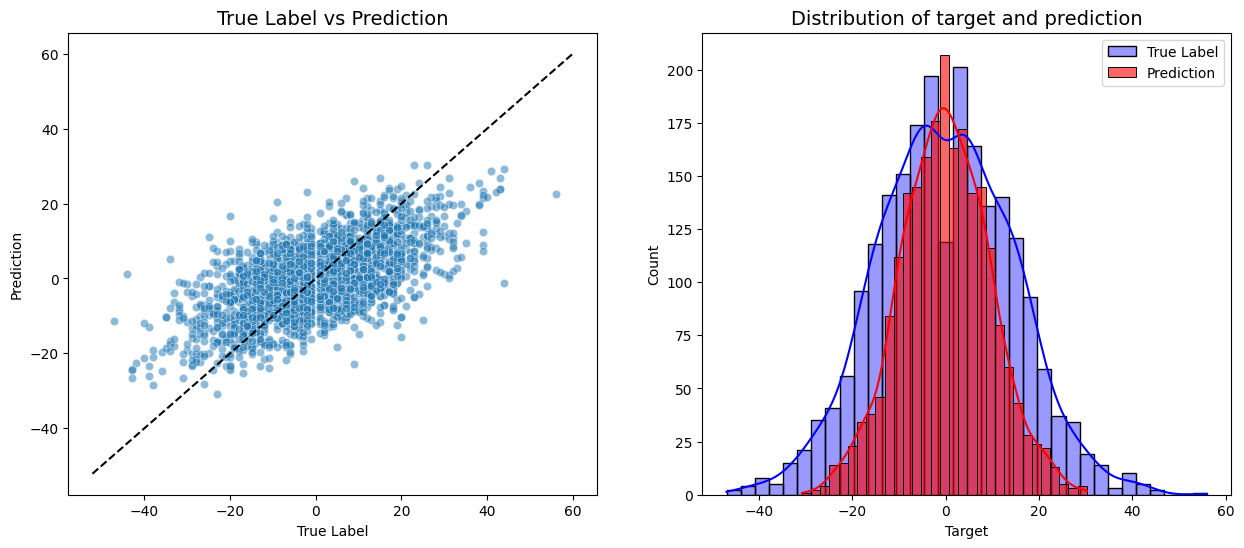

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


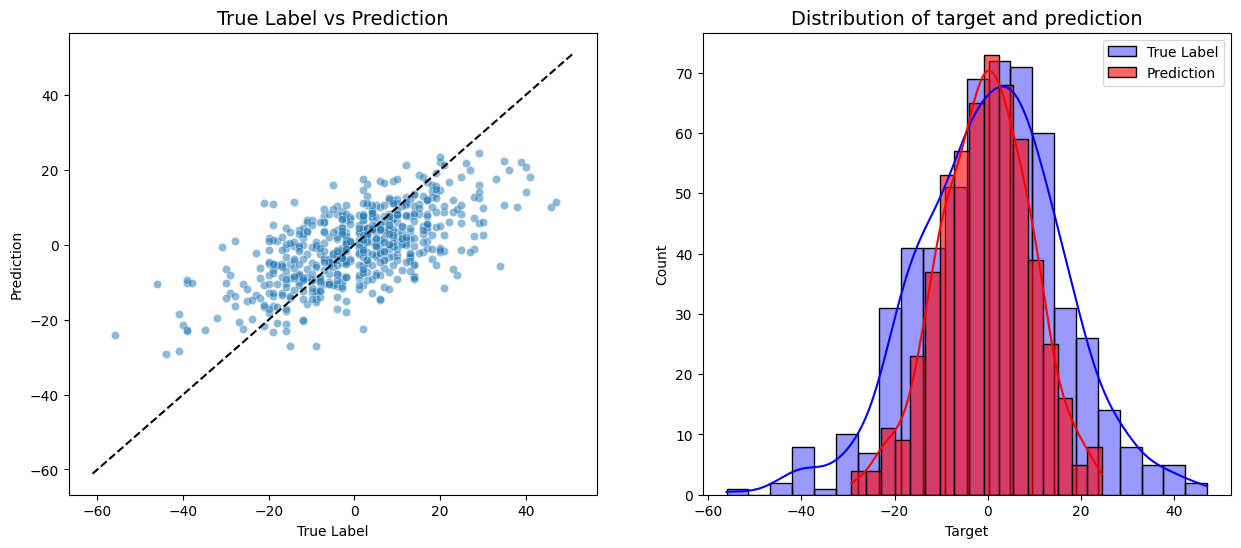

MAE train: 			 8.8397
MAE test: 			 9.1673
RMSE train: 			 11.2243
RMSE test: 			 11.8311
Accuracy train: 		 0.7201
Accuracy test: 			 0.7104
Logloss train: 			 0.5385
Logloss test: 			 0.5405
Brier train: 			 0.1822
Brier test: 			 0.1842
Unsure train: 			 17.06%
Unsure test: 			 17.63%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test
0,8.8397,9.1673,11.2243,11.8311,0.7201,0.7104,0.5385,0.5405,0.1822,0.1842,17.06,17.63


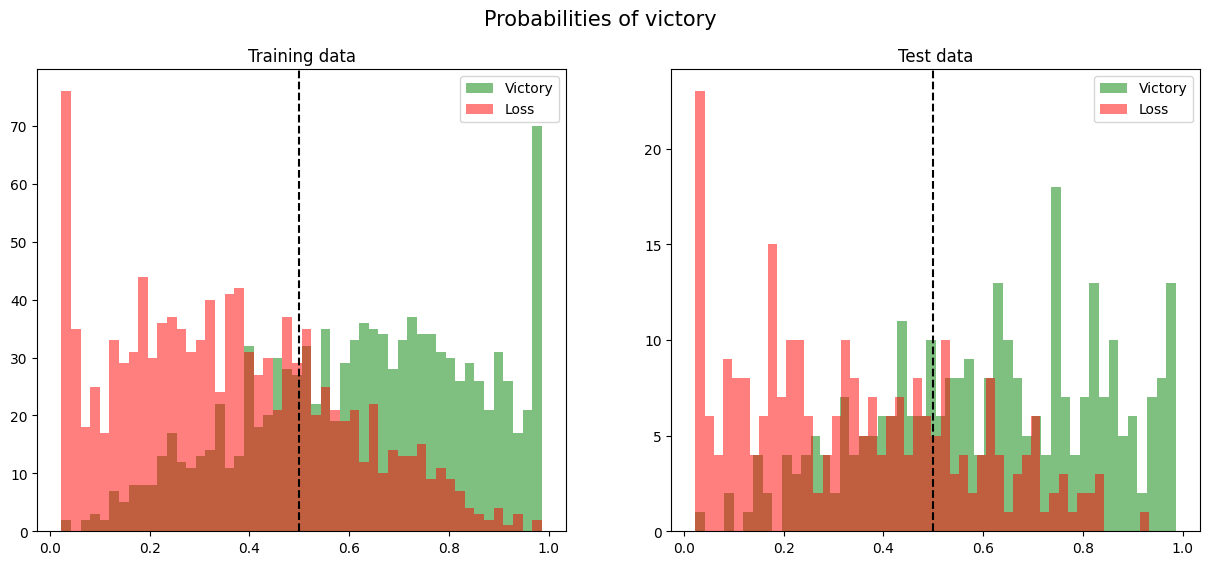

In [17]:
target = df_train["target_points"]

not_imp = [
 'delta_OT_win_perc',
 'delta_OT_win',
 'delta_Ast_TO_ratio_diff',
 'delta_Ast_TO_ratio',
 'delta_quality']

extras = [c for c in df_train if "stage" in c]
FEATURES = [c for c in df_train if "delta" in c and c not in DROP]
train = df_train[FEATURES].copy()
test_target = df_test["target_points"]
test = df_test[FEATURES].copy()

model = Ridge(random_state=34, alpha=0.1, max_iter=10000)

pipe = Pipeline([("scaler", tml.DfScaler()),
                ("model", model)])

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=None, early_stopping=False,
                                       shap=True, result_compare=None)


report_points(train=df_train, test=df_test, y_train=target, y_test=test_target, oof=oof, preds=pred, clip_val=21, padd=0.01)

In [18]:
pred_oof, pred_test = _point_to_proba(oof=oof, y_train=df_train["target_points"], preds=pred, clip_val=21, padd=0.01)
df_train["oof"] = oof
df_train["oof_prob"] = pred_oof
df_test ["pred"] = pred
df_test["pred_prob"] = pred_test

df_train["abs_err_points"] = (df_train["target_points"] - df_train["oof"]).abs()
df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["abs_err_points"] = (df_test["target_points"] - df_test["pred"]).abs()
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [19]:
df_train.groupby("stage_Round1")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round1,,
False,8.994302,0.203051
True,8.689202,0.161982


In [20]:
df_train.groupby("stage_Round2")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round2,,
False,8.821607,0.182327
True,8.892986,0.181981


In [21]:
df_train.groupby("stage_Round3")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round3,,
False,8.861776,0.178690
True,8.686526,0.206855


In [22]:
df_train.groupby("stage_Round4")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round4,,
False,8.794044,0.176678
True,9.523762,0.265577


In [23]:
df_train.groupby("stage_finalfour")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_finalfour,,
False,8.783864,0.180757
True,10.460236,0.225277


In [24]:
df_train.groupby("stage_final")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_final,,
False,8.851203,0.181986
True,8.098925,0.198515


In [29]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_finalfour"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_finalfour"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.1822393438443217
1 0.18224009144759604
2 0.18223702797249647
3 0.1822300432696794
4 0.18222262956281568
5 0.1822233623480608
6 0.1822385739934028
7 0.18226495668460024
8 0.18230468684485404
9 0.18235106934873344
10 0.18240380748286486
11 0.1824610532074373
12 0.18252150091145722
13 0.18257880859137027
14 0.18263797488643127
15 0.1826942524860691
16 0.18276840949319292
17 0.18286155346606306
18 0.1829665666826482
19 0.1830773227582558
20 0.1831928493109111
21 0.18331837965211406
22 0.18344470807128263
23 0.1835714974648045
24 0.18370053422196186


In [30]:
df_train.to_csv("data/results/men_train_ridge.csv", index=False)
df_test.to_csv("data/results/men_test_ridge.csv", index=False)